Group Sequence Policy Optimization（GSPO，组序列策略优化）由千问团队提出， 应用于 Qwen3 系列模型，
- <font color='red'>其核心思想返璞归真：奖励既然是给整个序列的，那么优化也应该在序列的层面上进行。<font>
- https://mp.weixin.qq.com/s/R6DsZxbHbH5PfxcSlZ-Mkg

论文：Group Sequence Policy Optimization[HuggingFace]

https://huggingface.co/papers/2507.18071

# 一、Motivation

GSPO的思想来源于强化学习实践中的观察，常见的强化学习过程可以用下面的伪代码[2]概括：

In [ ]:
for prompts in dataloader:

    # Stage 1: response生成
    batch = actor.generate_sequences(prompts)
    
    # Stage 2: 训练数据准备
    batch = critic.compute_values(batch)
    batch = reference.compute_log_prob(batch)
    batch = reward.compute_reward(batch)
    batch = compute_advantages(batch)
    
    # Stage 3: actor和critic训练
    critic_metrics = critic.update_critic(batch)
    actor_metrics = actor.update_actor(batch)

##### 第一阶段：响应生成（Response Generation） 在这个阶段，
- 当前的策略模型（actor）接收输入提示词（prompts），并生成相应的文本序列。这些生成的序列将作为后续训练的基础数据，代表了模型在当前策略下的行为表现。

###### 第二阶段：训练数据准备（Training Data Preparation） 这是强化学习的核心数据处理阶段，包含四个关键步骤：

- 价值估计：critic模型对生成的序列计算状态价值函数，预测每个状态的期望回报
- 参考概率计算：reference模型（通常是原始的预训练模型）计算生成序列的对数概率，用于后续的KL散度约束，防止策略偏离过远
- 奖励计算：reward模型根据预设的奖励函数对生成的序列进行评分，这通常反映了人类偏好或任务目标
- 优势函数计算：基于奖励和价值估计计算优势函数（advantages），用于指导策略梯度的更新方向

##### 第三阶段：模型参数更新（Model Parameter Update） 利用准备好的训练数据，分别更新两个核心组件：

- Critic更新：使用时序差分（TD）误差或其他价值函数学习方法优化critic网络，提高价值估计的准确性
- Actor更新：基于策略梯度方法（如PPO）更新actor网络参数，利用优势函数引导策略朝着更高奖励的方向优化

为了提升采样效率，各个强化学习框架中通用的做法是将一个巨大 batch size 的 rollout 数据（第一阶段一次性完成大量推理）拆分成很多 mini-batch 来进行梯度更新，由于梯度更新发生了多次，这个过程不可避免地形成了 off-policy learning（离线学习）——Response 来自旧的策略模型$θ_old$而非当前最新的模型 θ 。

In [1]:
from IPython.display import Image

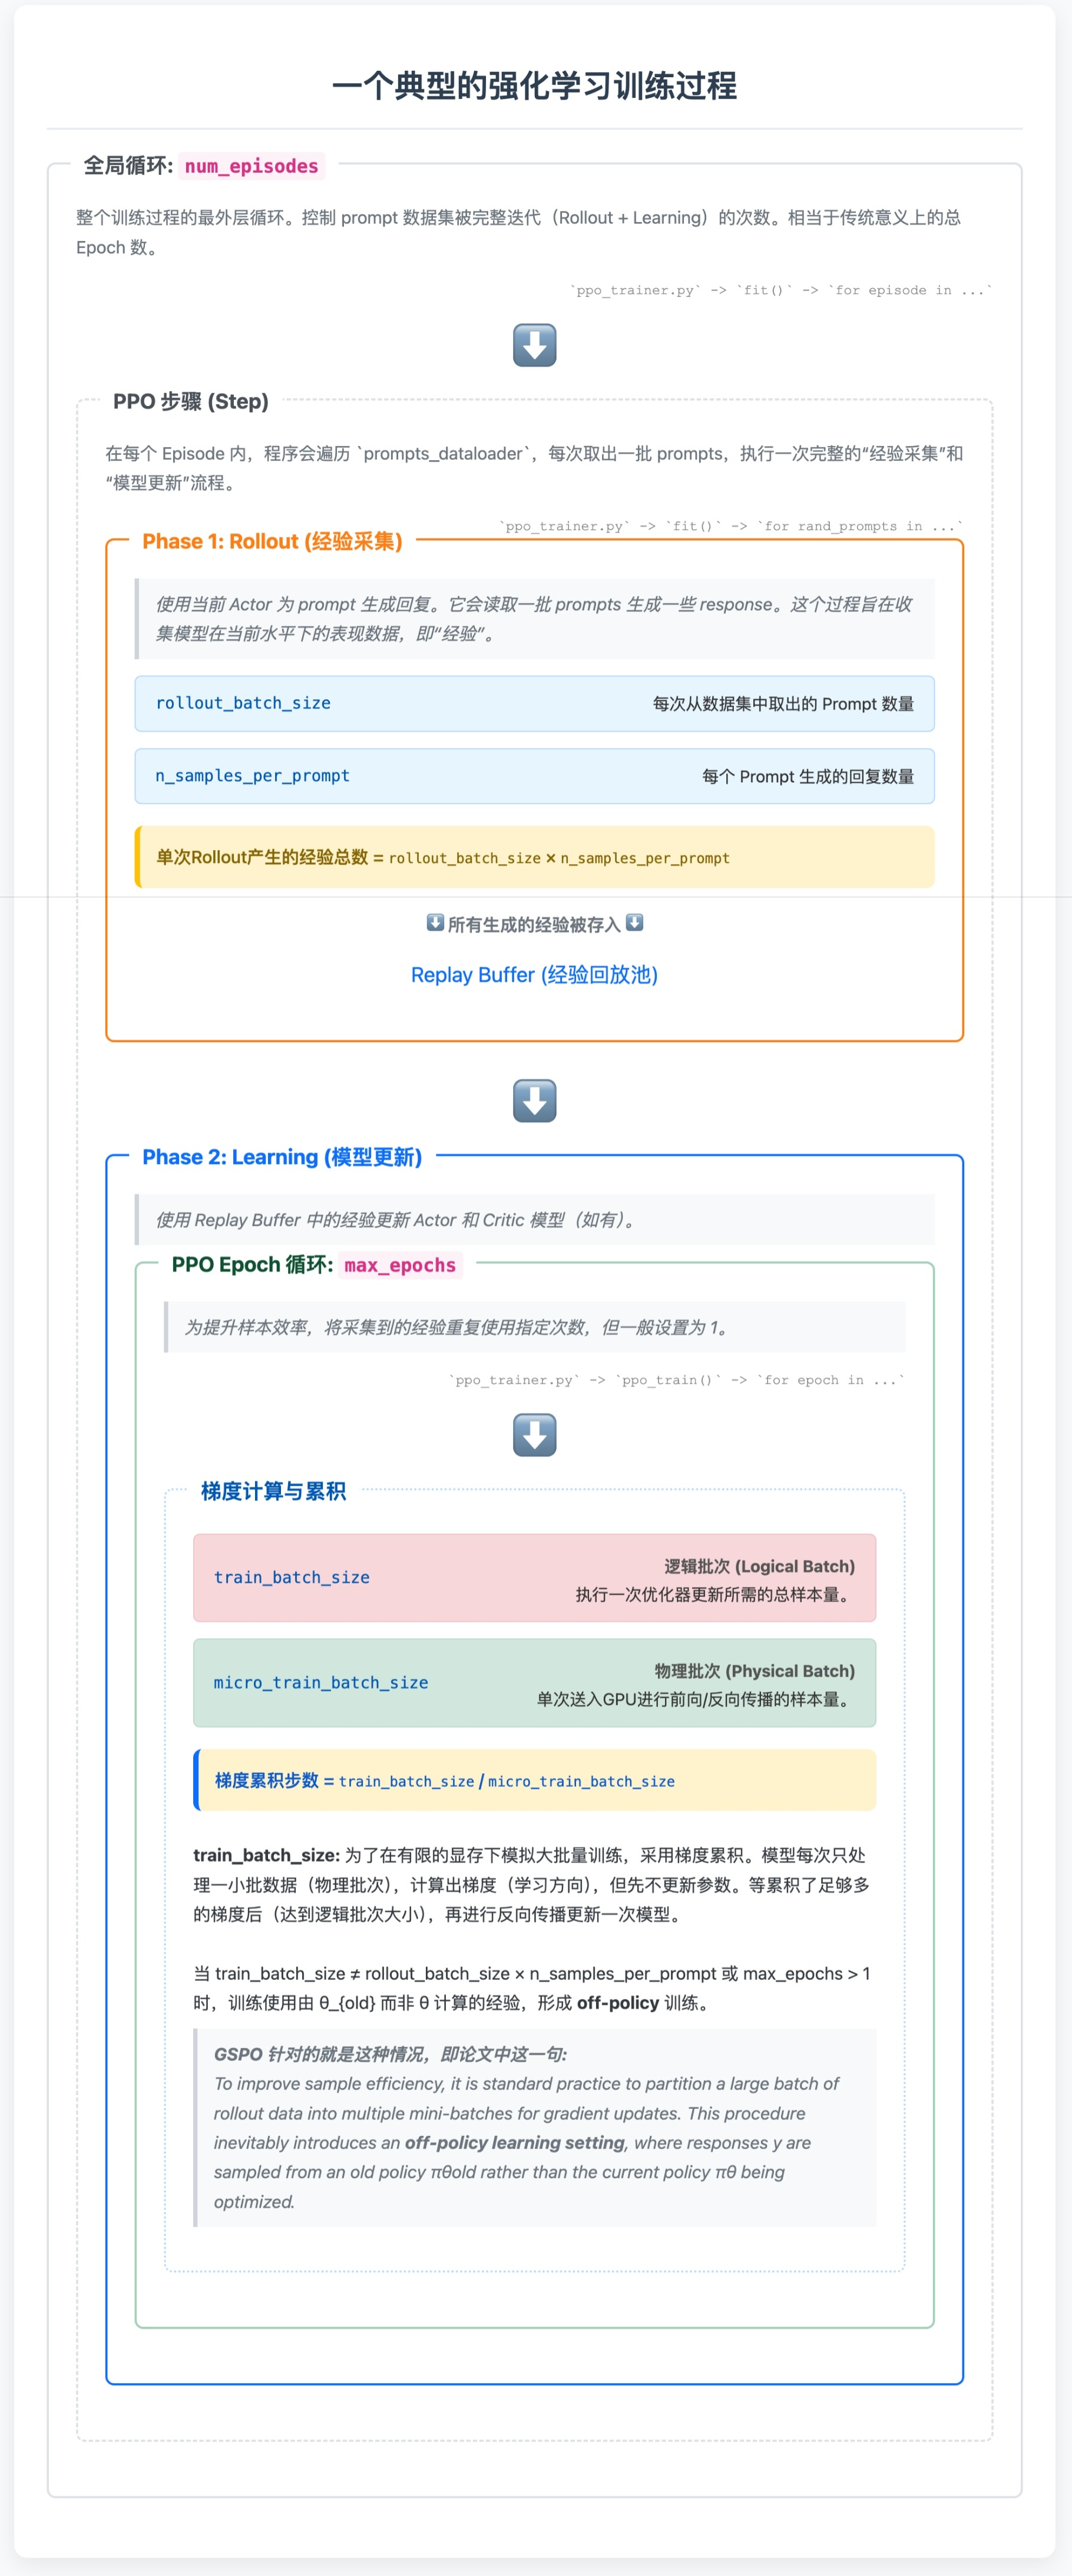

In [2]:
Image(filename='./image/rl_train_steps.png',width=600)

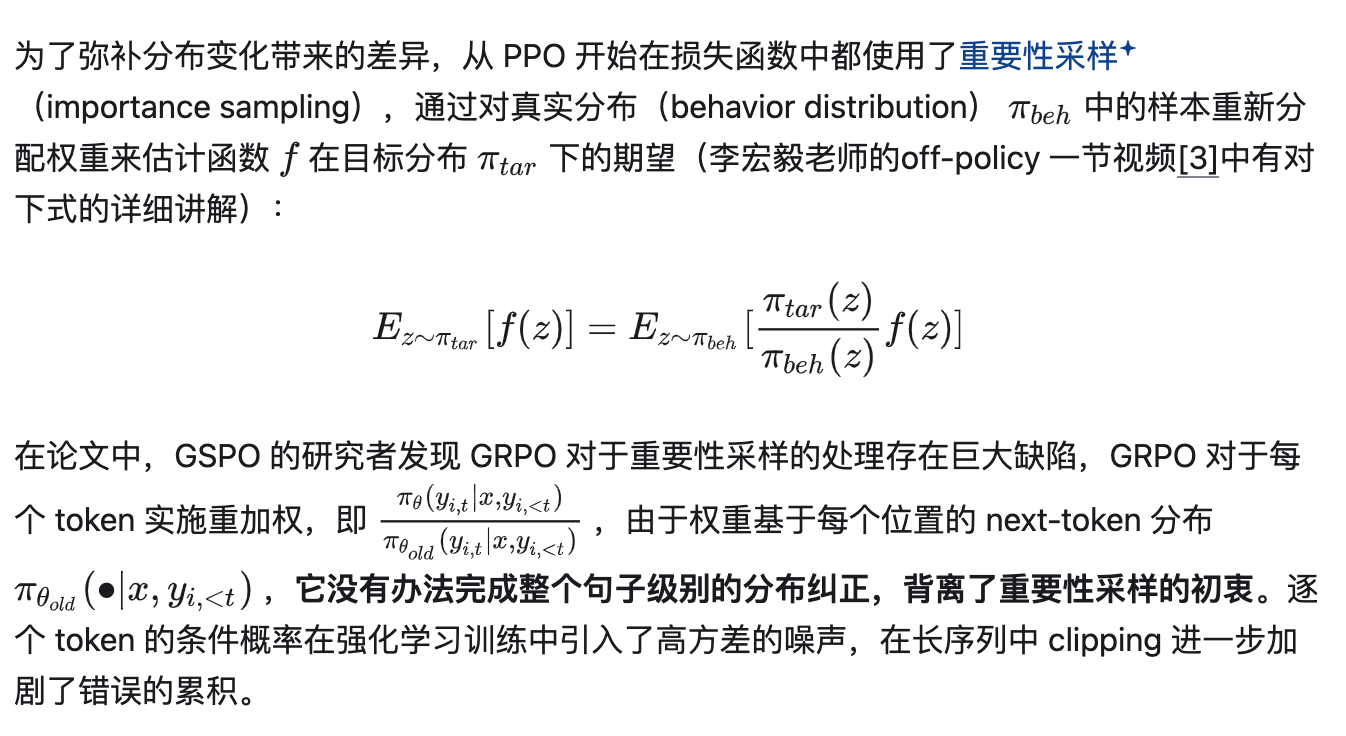

In [3]:
Image(filename='./image/gspo_01.png',width=600)

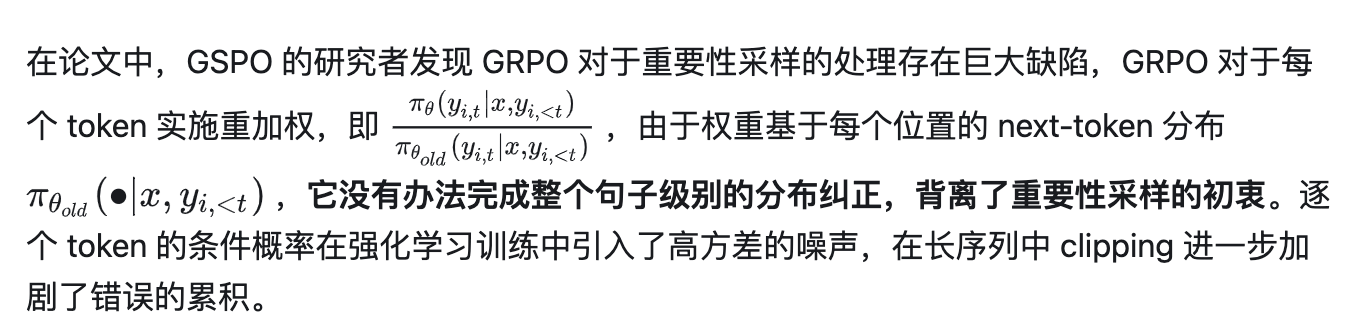

In [4]:
Image(filename='./image/gspo_02.png',width=600)

那么，GRPO 为什么要使用这种逐 token 的重要性采样呢？原因是，向来如此。

自 RLHF 被引入 LLM 的训练中以来，使用的 PPO 算法及其变体，都将 LLM 输出一个 token 视为一个 action，自 PPO 开始，重要性采样在 token 级别进行都是把 token 当作 action 的结果，甚至于奖励 Reward 和优势 Advantage 的计算都要服从 action 的频率，变成一个 token 一个奖励/优势（将 Reward model 所天然具有的结果奖励通过反向遍历序列计算GAE的方式变成每个 token 的 $A_t$
 ）。

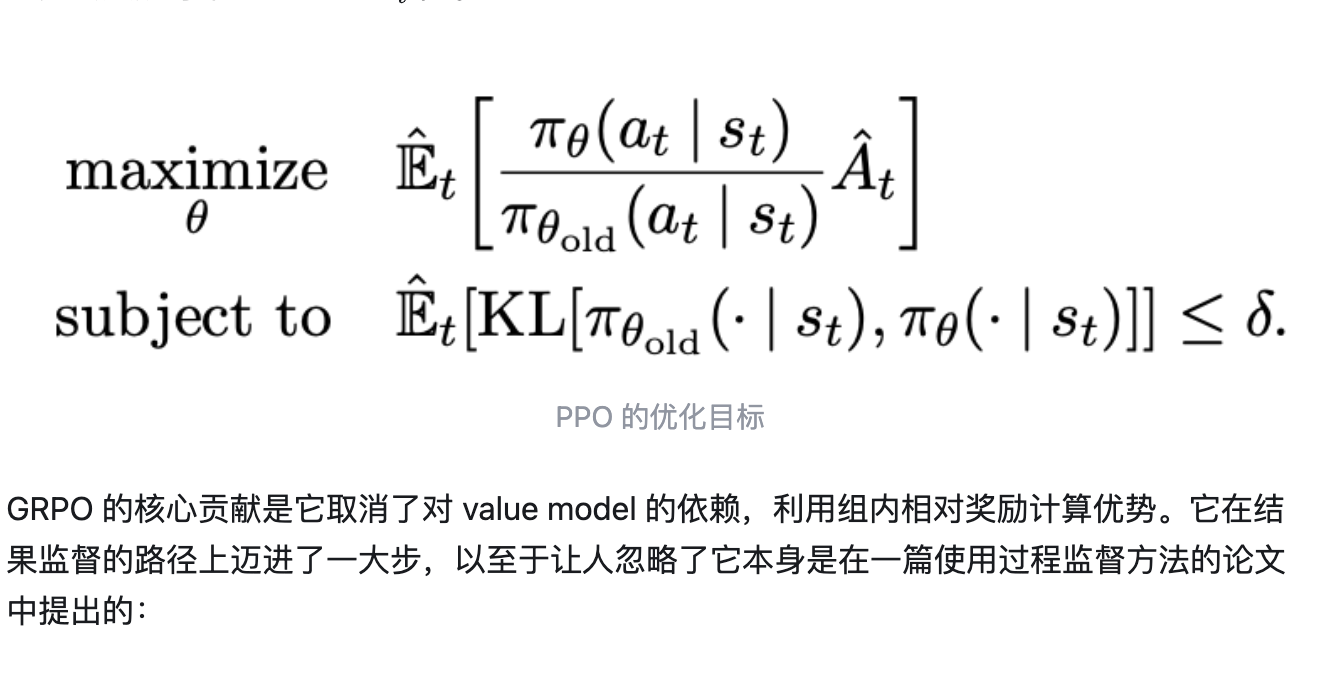

In [5]:
Image(filename='./image/ppo_target_optimize.png',width=600)

GRPO 的核心贡献是它取消了对 value model 的依赖，利用组内相对奖励计算优势。它在结果监督的路径上迈进了一大步，以至于让人忽略了它本身是在一篇使用过程监督方法的论文中提出的：

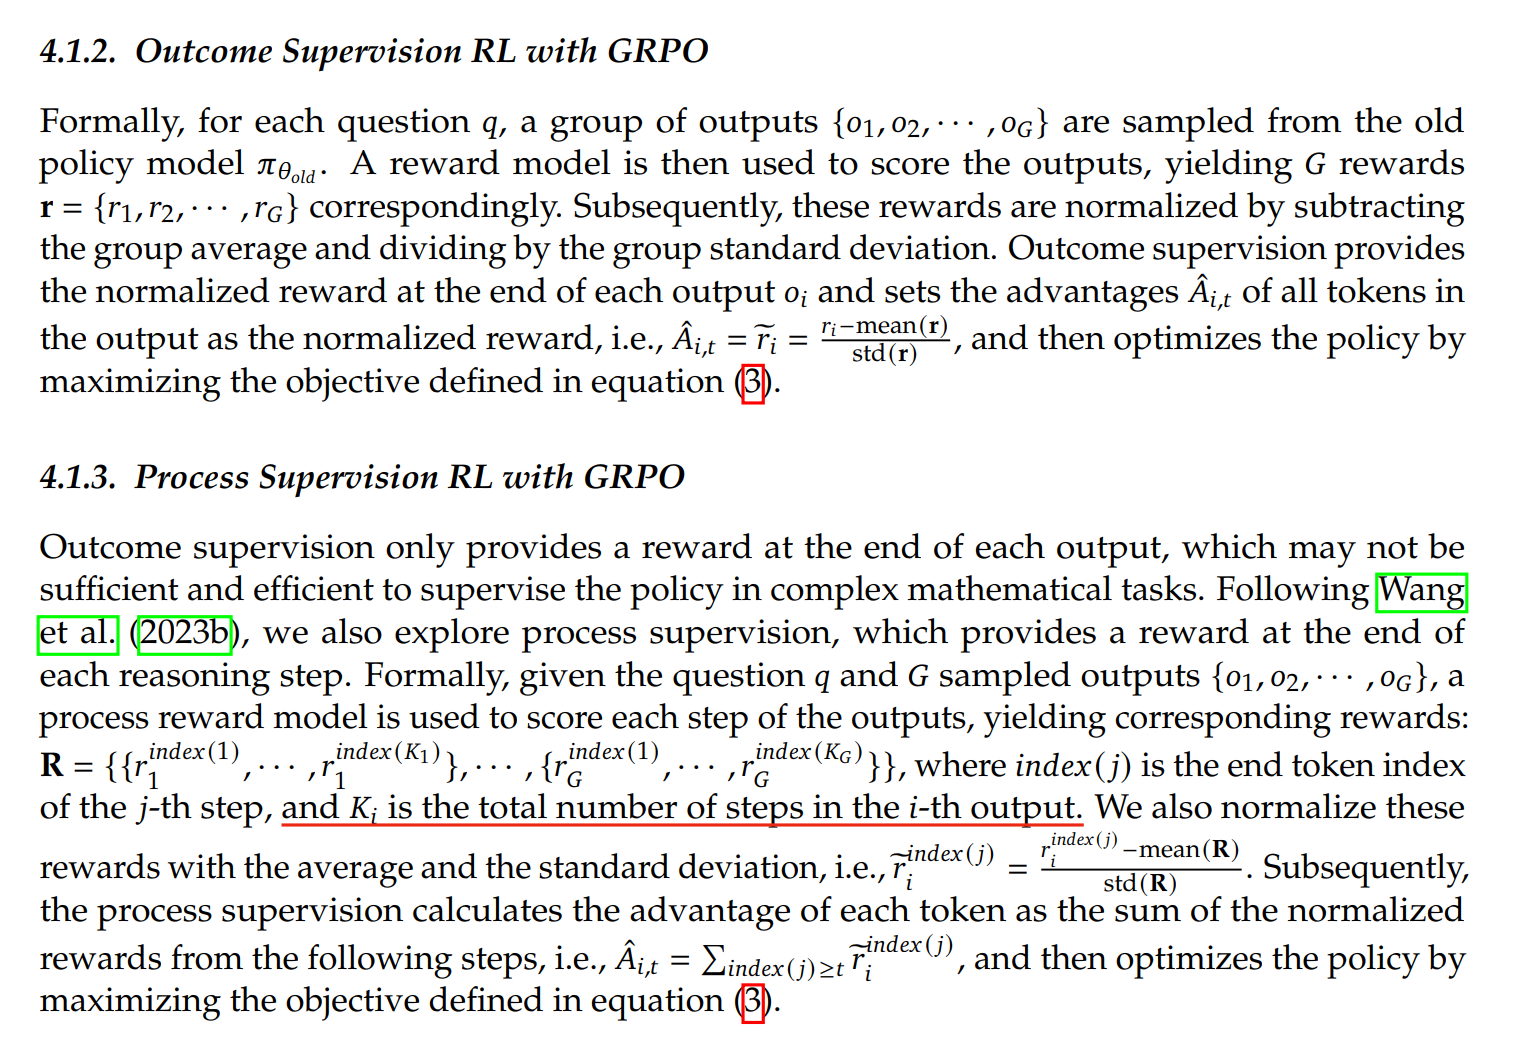

In [7]:
Image(filename='./image/rl.png',width=600)

大家熟知的是 GRPO 结果监督中对奖励的硬估计（数学题对就是 1，错就是 0），但 GRPO 保持了对过程监督的兼容，逐 token 的奖励并没有被抛弃，毕竟在当时过程监督就是大行其道。

到现在，结果监督已经被证明是简单且高效的， GSPO 才能反其道而行之——要用 action 去适配奖励，而不是用奖励去适配 action。既然奖励是对于一个 sequence 产生的，那么 action 就应该被定义为一个 sequence，重要性采样也就要在 action/sequence 的维度进行。



### 二、算法细节
GSPO与 GRPO 的差异仅仅是重要性采样的权重不同。

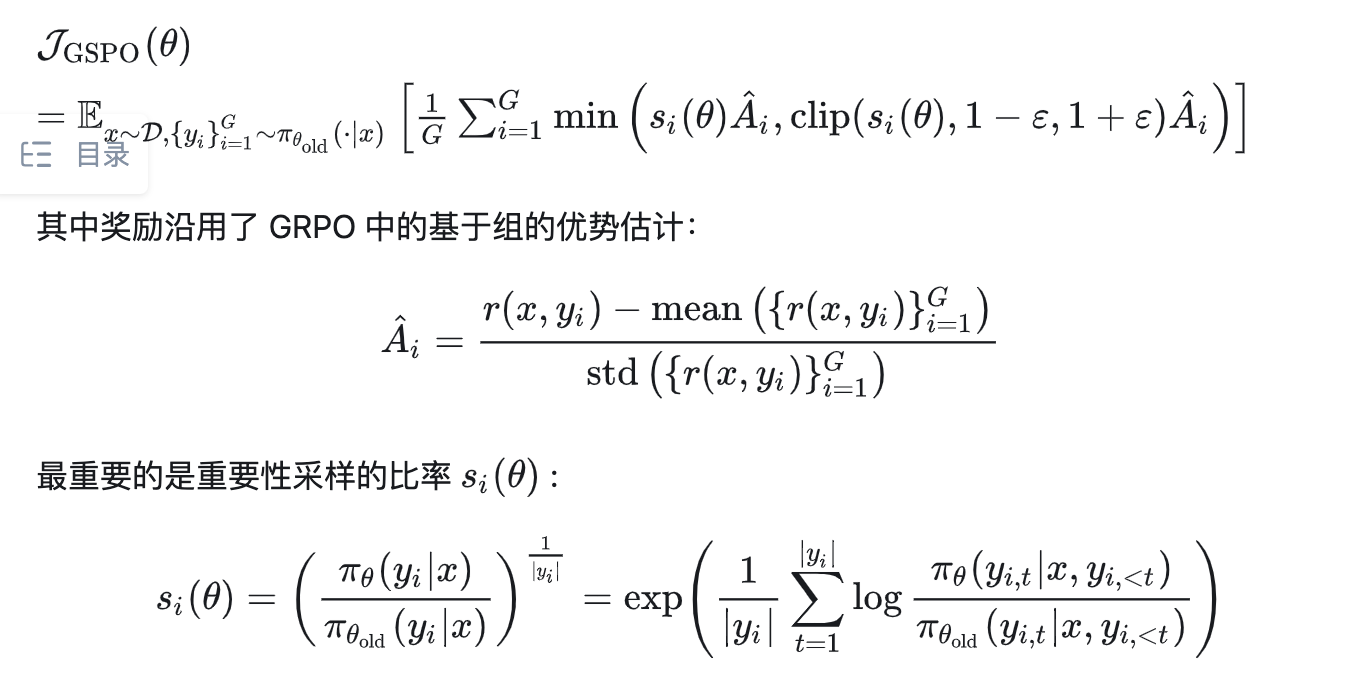

In [8]:
Image(filename='./image/gspo_grpo_diff.png',width=600)

 $s_i(θ)$使用长度归一化来减少方差并且控制数值范围不过高，我们来深入分析一下其背后的原因和合理性，
 
 主要可以归结为以下两点：

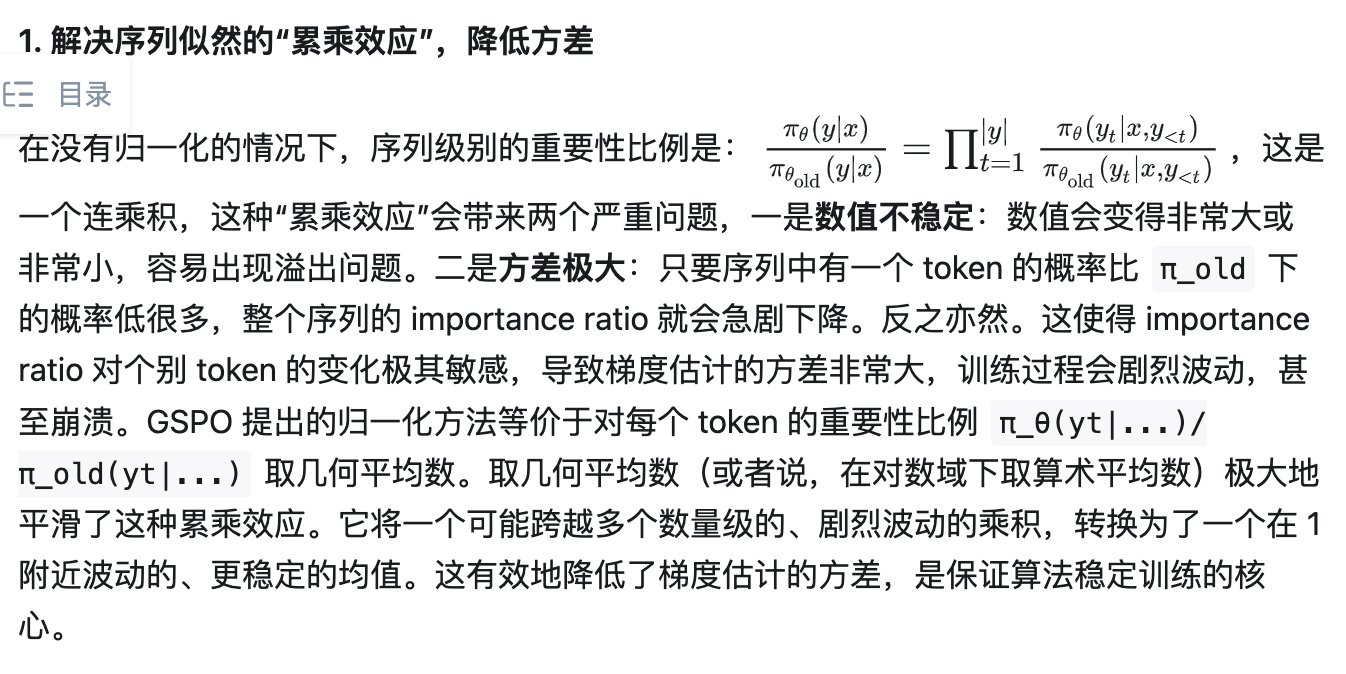

In [9]:
Image(filename='./image/diff_01.png',width=600)

如论文 4.1 节所述：

Note that we adopt length normalization in si(θ) to reduce the variance and to control si(θ) within a unified numerical range. Otherwise, the likelihood changes of a few tokens can result in dramatic fluctuations of the sequence-level importance ratio...

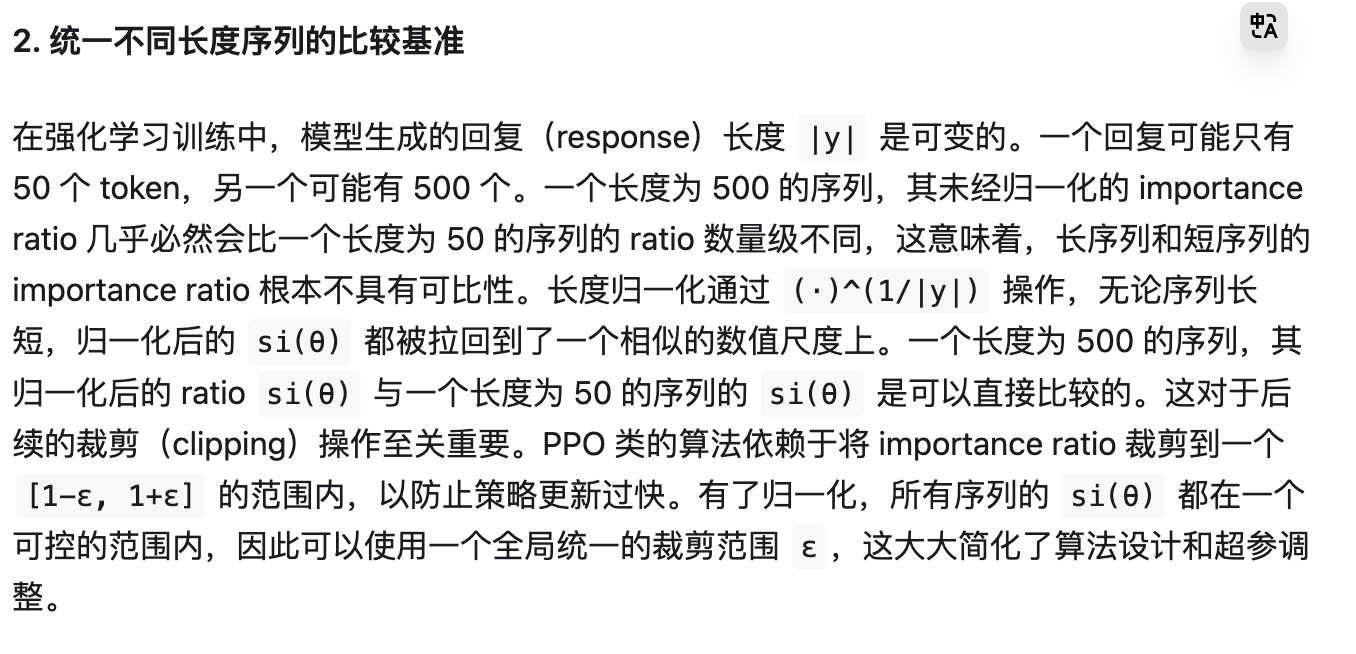

In [10]:
Image(filename='./image/diff_02.png',width=600)

如论文 4.1 节所述：

...and the importance ratios of responses with different lengths will require varying clipping ranges.

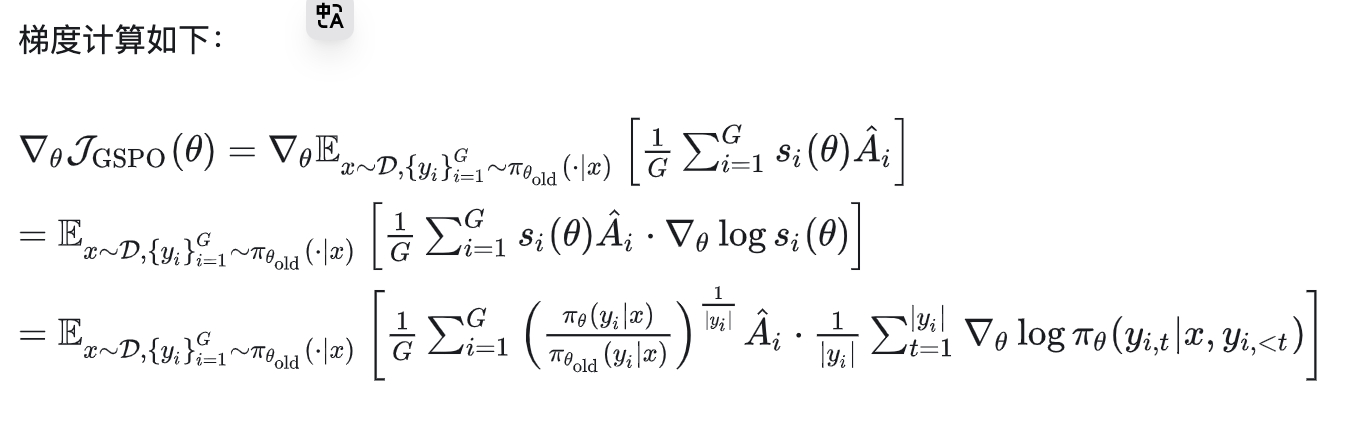

In [11]:
Image(filename='./image/diff_gard.png',width=600)

# 三、对比分析
将 GSPO 和 GRPO 总结对比如下图：

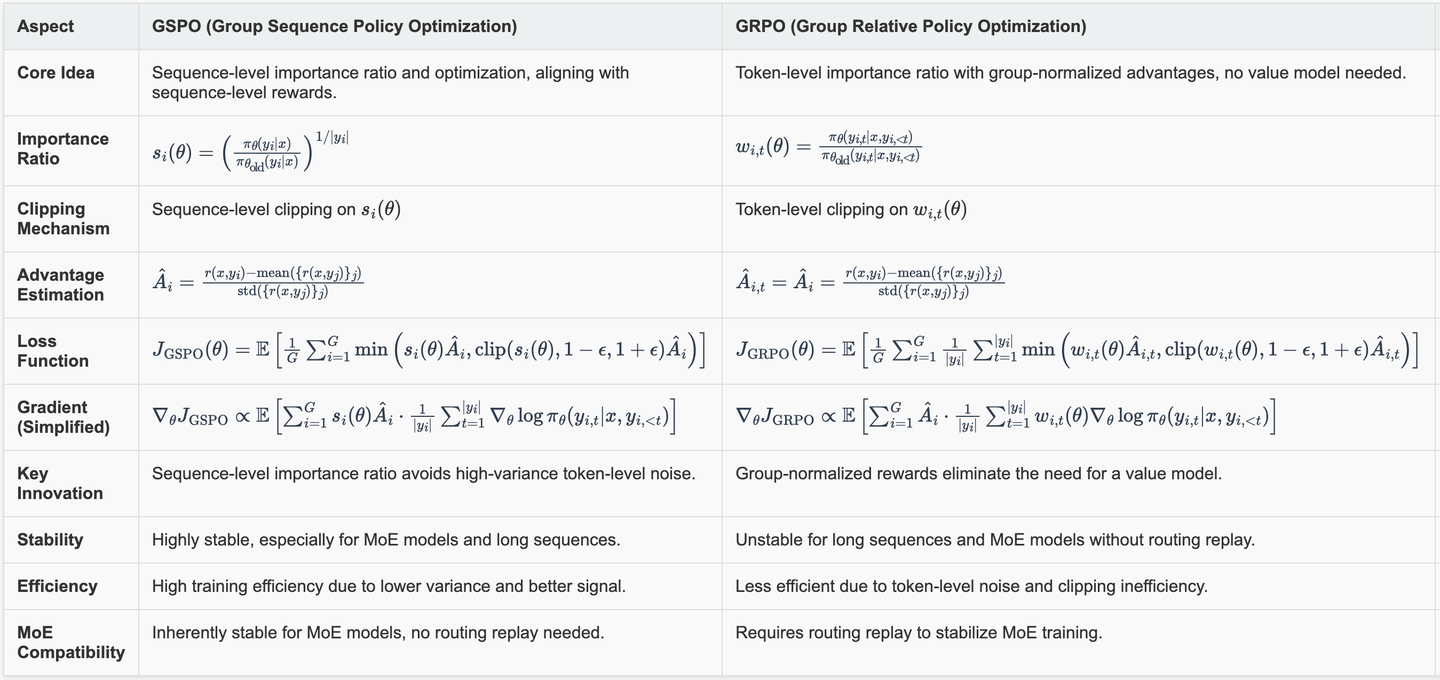

In [12]:
Image(filename='./image/grpo_gspo_compre.png')

另一个经常被拿来和这两种算法对比的是字节的 DAPO[4]，之前读这篇论文的时候没写博客解读，一是改动不大，二是觉得强化学习很多算法没法定量对比（与数据也有很大关系，有时候甚至觉得奖励方差大一点也没关系，只要均值较好就有效果），并不是说 DAPO 提出的方法不重要，clipping 对于低概率的 token 不友好，限制了模型的探索空间，这是非常重要的洞察。

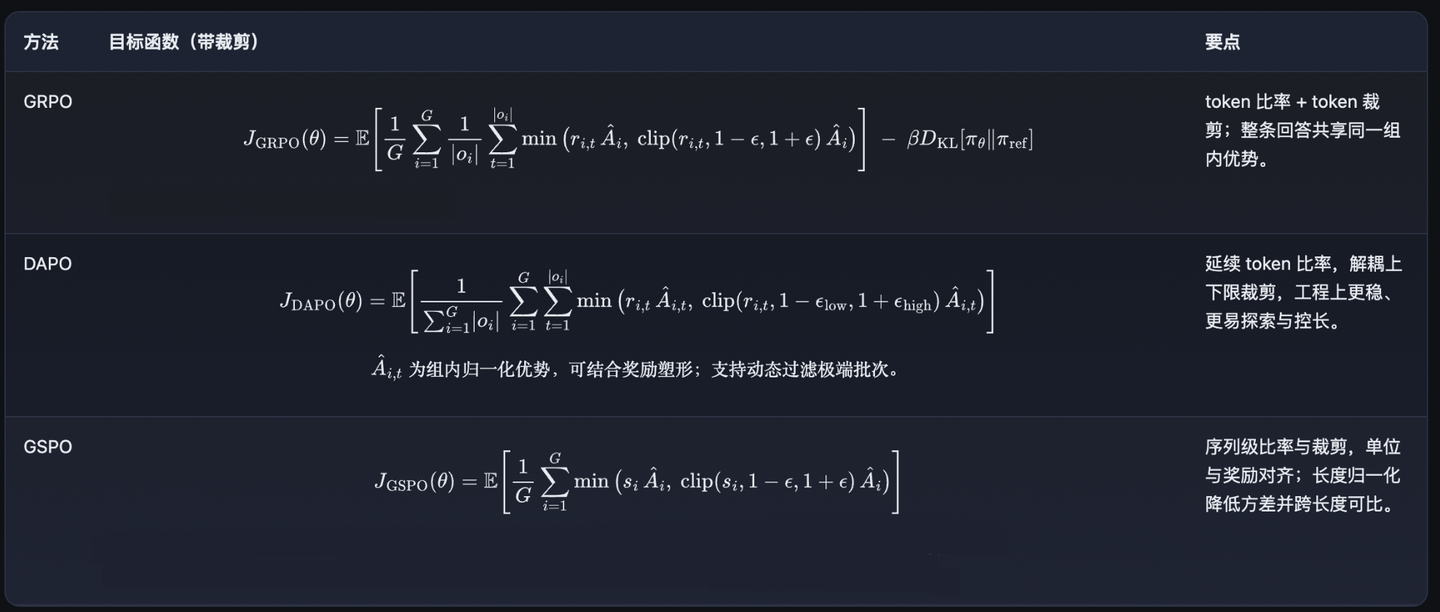

In [13]:
Image(filename='./image/GRPO vs DAPO vs GSPO.png')

# 附

最近读了一篇定性分析强化学习的各种策略的论文，觉得很有收获值得一读[5]，有意思的是这篇论文里把 GRPO 称为 sequence 级别的优化 。
- https://arxiv.org/abs/2508.08221

# 解密Qwen3三连发：强化学习新算法GSPO！

强化学习 （Reinforcement Learning，RL）已成为拓展语言模型、增强其深度推理与问题求解能力的关键技术范式。为了持续拓展 RL，首要前提是确保稳定、鲁棒的训练过程。然而，我们观察到现有的 RL 算法（如 GRPO）在长期训练中会暴露出严重的不稳定性问题并招致不可逆转的模型崩溃，阻碍了通过增加计算以获得进一步的性能提升。

为了能够持续拓展 RL，我们提出了 Group Sequence Policy Optimization (GSPO) 算法。不同于过去的 RL 算法，GSPO 定义了序列级别的重要性比率，并在序列层面执行裁剪、奖励和优化。相较于 GRPO，GSPO 在以下方面展现出突出优势：
- 强大高效：GSPO 具备显著更高的训练效率，并且能够通过增加计算获得持续的性能提升；
- 稳定性出色：GSPO 能够保持稳定的训练过程，并且根本地解决了混合专家（Mixture-of-Experts，MoE）模型的 RL 训练稳定性问题；
- 基础设施友好：由于在序列层面执行优化，GSPO 原则上对精度容忍度更高，具有简化 RL 基础设施的诱人前景。

以上优点促成了最新的 Qwen3 模型（Instruct、Coder、Thinking）的卓越性能。

论文链接：
- https://www.arxiv.org/abs/2507.18071
- https://huggingface.co/papers/2507.18071

# 序列级别的优化目标



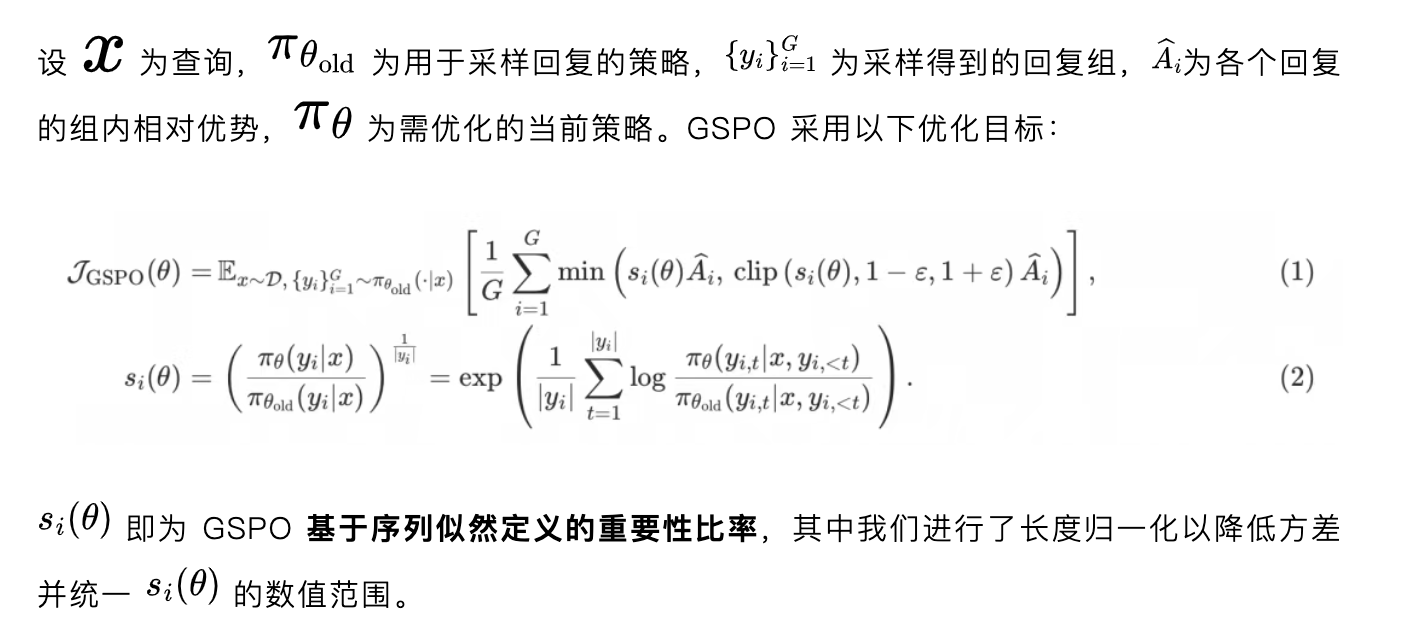

In [14]:
Image(filename='./image/gspo_sequence.png',width=600)

# 训练效率与性能

我们使用基于 Qwen3-30B-A3B-Base 微调得到的冷启动模型进行实验，并汇报其训练奖励曲线以及在 AIME'24、LiveCodeBench 和 CodeForces 等基准上的性能曲线。我们对比 GRPO 作为基线。
- 注意 GRPO 必需采用 Routing Replay 训练策略才能正常收敛（我们将在后文讨论），而 GSPO 则无需该策略。

从下图可见，GSPO 表现出比 GRPO 显著更高的训练效率，即在同等计算开销下能够取得更优的性能。特别地，我们观察到 GSPO 可以通过增加算力来获得持续的性能提升——这正是我们所期待的算法的可拓展性。最终，我们成功地将 GSPO 应用于最新的 Qwen3 模型的大规模 RL 训练，进一步释放了 RL scaling 的潜能！

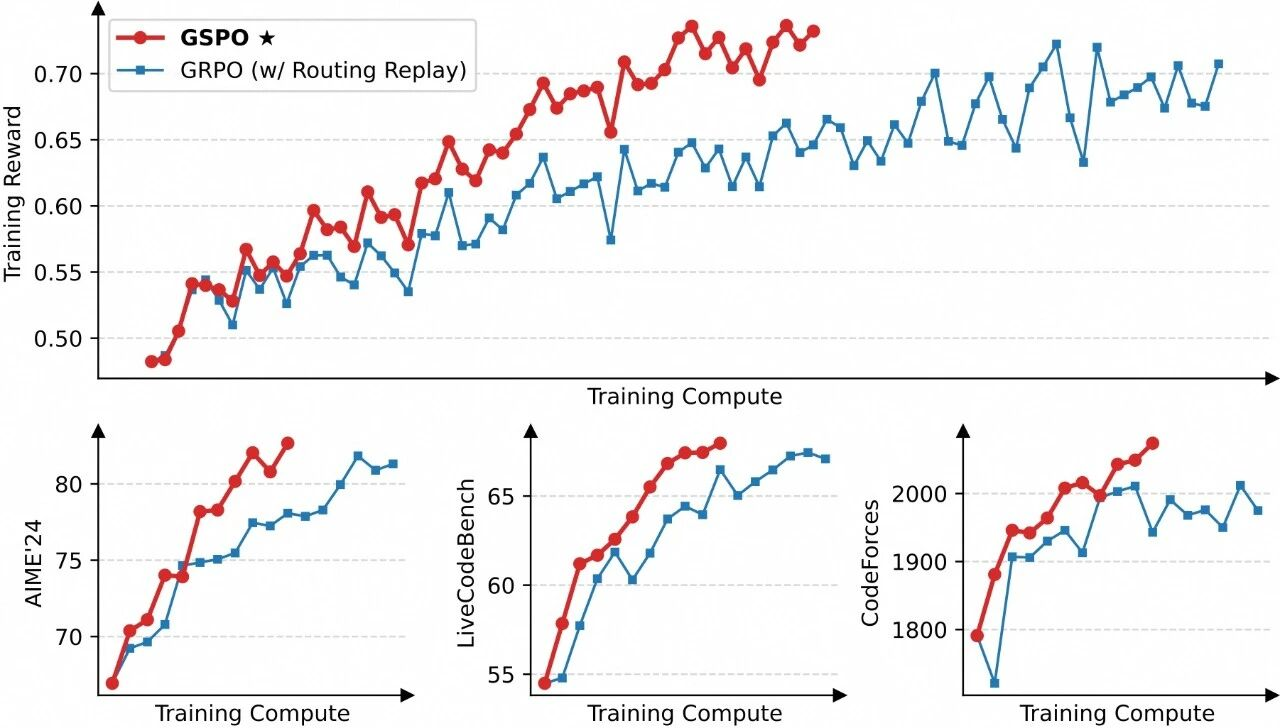

In [15]:
Image(filename='./image/gspo_grpo_chart.jpg',width=600)

一个有趣的观察是，GSPO 所裁剪的 token 比例比 GRPO 要高上两个数量级（如下图所示），但却具有更高的训练效率。这进一步表明 GRPO 采用的 token 级别的优化目标是有噪和低效的，而 GSPO 的序列级别的优化目标则提供了更可靠、有效的学习信号。

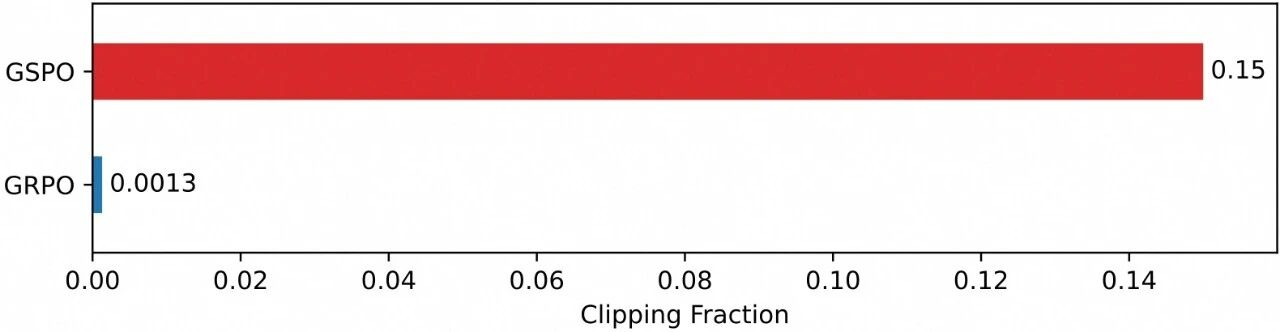

In [16]:
Image(filename='./image/gspo_clip.jpg',width=600)

# 对MoE RL和基础设施的收益

我们发现，当采用 GRPO 算法时，MoE 模型的专家激活波动性会使得 RL 训练无法正常收敛。为了解决这一挑战，我们过去采用了路由回放（Routing Replay）训练策略，即缓存$π_{θ_{old}}$中激活的专家，并在计算重要性比率时在$π_θ$中“回放”这些路由模式。下图可见，Routing Replay 对于 GRPO 训练 MoE 模型的正常收敛至关重要。然而，Routing Replay 的做法会产生额外的内存和通信开销，并可能限制 MoE 模型的实际可用容量。

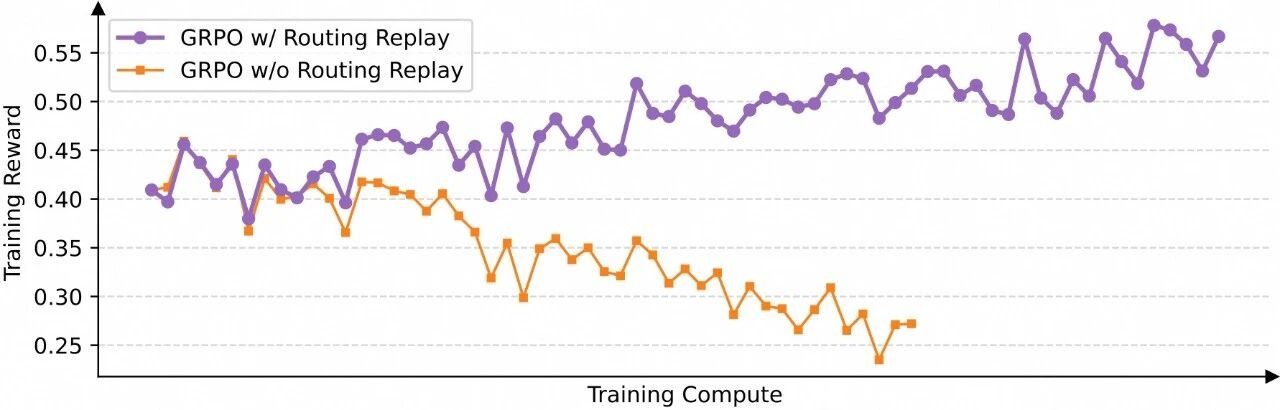

In [17]:
Image(filename='./image/moe_grpo.jpg',width=600)

GSPO 的一大突出优势在于彻底消除了对 Routing Replay 的依赖。其核心洞见在于：GSPO 仅关注序列级别的似然（即$π_θ(y_i | x)$ ），而对个别 token 的似然（即$π_θ(y_i | x,y_i < t)$ ）不敏感。因此，其无需 Routing Replay 等对基础设施负担较大的手段，既简化和稳定了训练过程，又使得模型能够最大化地发挥容量与潜能。
此外，鉴于 GSPO 仅使用序列级别而非 token 级别的似然进行优化，直观上前者对精度差异的容忍度要高得多。因此，GSPO 使得直接使用推理引擎返回的似然进行优化成为可能，从而无需使用训练引擎重新计算，这在 partial rollout、多轮 RL 以及训推分离框架等场景中特别有益。

# 结论
我们提出了 Group Sequence Policy Optimization (GSPO)，这是用于训练语言模型的全新 RL 算法。相较于 GRPO，GSPO 在训练稳定性、效率和性能方面展现出显著优势，并在 MoE 模型的大规模 RL 训练中表现出突出的功效。这些优点为最新 Qwen3 模型的卓越性能奠定了算法基础。以 GSPO 作为算法基石，我们将持续推动 RL scaling 的边界，并期待由此带来的智能进步。